In [1]:
import sys
sys.path.insert(0, '..')
from cr.orbits import get_edge_orbits
import numpy as np
import matplotlib.pyplot as plt

## Example 7.6: Non-Cayley Vertex-Transitive Graph (20,10)

Let $G$ be the non-Cayley vertex-transitive (20,10) graph from Mathematica on $n = 20$ vertices. Under the full automorphism group $\Psi = \operatorname{Aut}(G)$ of order $160$, $G$ has two edge orbits of sizes $40$ and $10$. We certify lower and upper conformal rigidity exactly by finding 1-dimensional orbit-isometric embeddings on $\mathcal{E}_{\lambda_2}$ and $\mathcal{E}_{\lambda_n}$. We follow the procedure in `crossing_number_6b.ipynb`. We will see that we cannot read off a real solution from a Gröbner basis, but we can still easily find a solution using Theorem 7.3.

n = 20, m = 50


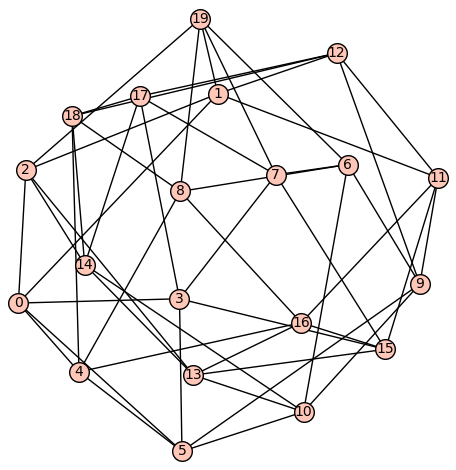

In [2]:
G = Graph('S{aW?cI@_KgAODGAC@GaIAHSPA_PDJF??')
n, m = G.order(), G.size()
print(f'n = {n}, m = {m}')
G.plot()

### Edge orbits

We compute $\Psi = \operatorname{Aut}(G)$ and partition the edges into orbits.

In [3]:
aut_group = G.automorphism_group()
edge_orbits = get_edge_orbits(G, aut_group.gens())
print(f'|Aut(G)| = {aut_group.order()}')
print(f'Edge orbits: {len(edge_orbits)}, sizes = {[len(o) for o in edge_orbits]}')

|Aut(G)| = 160
Edge orbits: 2, sizes = [40, 10]


$G$ has two edge orbits of sizes $40$ and $10$.

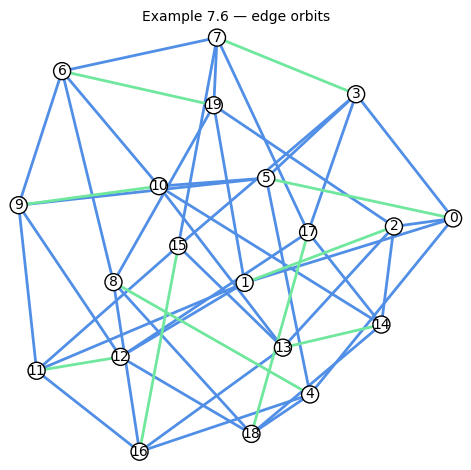

In [4]:
palette = ['#518FE7', '#6FE79D']
edge_colors = {palette[i]: [tuple(e) for e in orbit]
               for i, orbit in enumerate(edge_orbits)}
G.plot(edge_colors=edge_colors, vertex_size=150,
       vertex_colors={'white': G.vertices(sort=True)},
       edge_thickness=2, title='Example 7.6 — edge orbits')

## Lower Conformal Rigidity ($\lambda_2$)

We want an orbit-isometric embedding on $\mathcal{E}_{\lambda_2}$. Writing $\varphi = Bx$ for a basis $B$ of $\mathcal{E}_{\lambda_2} \cong \mathbb{R}^7$, the orbit-isometry conditions become
$$\langle Bx,\, L_i\, Bx \rangle = |O_i|, \qquad i = 1, 2.$$

### Exact $\lambda_2$-eigenspace

Since $\lambda_2$ is irrational we work over $\mathbb{A}$.

In [5]:
L = G.laplacian_matrix().change_ring(AA)
lam2 = sorted(L.eigenvalues())[1]
E = (L - lam2 * matrix.identity(n)).kernel()
basis2 = E.basis()
d2 = len(basis2)
print(f'lambda_2 = {lam2.radical_expression()},  dim E_lambda2 = {d2}')

lambda_2 = -sqrt(5) + 5,  dim E_lambda2 = 7


Even though Sage displays floating-point approximations for elements of $\mathbb{A}$, everything is stored exactly as a minimal polynomial. We can inspect the exact entries:

In [6]:
for phi in basis2:
    print([v.radical_expression() for v in phi])

[1, 0, 0, 0, 0, sqrt(5), 0, 1/2*sqrt(5) - 5/2, 1/2*sqrt(5) - 5/2, 2, 2, 0, sqrt(5) - 2, 0, sqrt(5) - 2, -1/2*sqrt(5), -1/2*sqrt(5), -sqrt(5) + 3/2, -sqrt(5) + 3/2, -sqrt(5) + 1]
[0, 1, 0, 0, 0, -1, 0, 1/2*sqrt(5) - 1/2, 1/2*sqrt(5) - 1/2, -1/2*sqrt(5) + 1/2, -1/2*sqrt(5) - 1/2, 0, sqrt(5) - 1, -1/2*sqrt(5) - 1/2, 1/2*sqrt(5) - 3/2, -1/4*sqrt(5) - 1/4, -1/4*sqrt(5) - 1/4, -1/4*sqrt(5) + 7/4, -1/4*sqrt(5) + 7/4, 1]
[0, 0, 1, 0, 0, -1, 0, 1/2*sqrt(5) - 1/2, 1/2*sqrt(5) - 1/2, -1/2*sqrt(5) - 1/2, -1/2*sqrt(5) + 1/2, 0, -2, 1/2*sqrt(5) + 1/2, 1/2*sqrt(5) - 3/2, 1/4*sqrt(5) + 5/4, 1/4*sqrt(5) + 5/4, -3/4*sqrt(5) + 1/4, -3/4*sqrt(5) + 1/4, 1]
[0, 0, 0, 1, 0, -1, 0, 1/2*sqrt(5) + 1/2, 1/2*sqrt(5) - 1/2, -1/2*sqrt(5) - 1/2, -1/2*sqrt(5) - 1/2, 0, -1, 0, -1, 1/2*sqrt(5) + 1/2, 1, 0, -1/2*sqrt(5) + 1/2, 1]
[0, 0, 0, 0, 1, -1, 0, 1/2*sqrt(5) - 1/2, 1/2*sqrt(5) + 1/2, -1/2*sqrt(5) - 1/2, -1/2*sqrt(5) - 1/2, 0, -1, 0, -1, 1, 1/2*sqrt(5) + 1/2, -1/2*sqrt(5) + 1/2, 0, 1]
[0, 0, 0, 0, 0, 0, 1, 1/2*sqrt

### Orbit-isometry ideal and Gröbner basis

We form the ideal $I_2 \subseteq \mathbb{A}[x_0,\ldots,x_6]$ generated by the two orbit-energy equations.

In [7]:
R2 = PolynomialRing(AA, names=[f'x{i}' for i in range(d2)], order='lex')
x2 = R2.gens()

equations2 = []
for orbit in edge_orbits:
    energy = R2(0)
    for u, v in orbit:
        phi_u = sum(x2[j] * basis2[j][u] for j in range(d2))
        phi_v = sum(x2[j] * basis2[j][v] for j in range(d2))
        energy += (phi_u - phi_v)**2
    equations2.append(energy - len(orbit))

I2 = R2.ideal(equations2)
print(f'Ideal dimension: {I2.dimension()}')

Ideal dimension: 5


The variety $V(I_2)$ is $5$-dimensional — $7$ free variables constrained by only $2$ equations. A Gröbner basis describes it implicitly, but reading off a real orbit-isometric vector by hand from these expressions is not feasible:

In [8]:
gb2 = I2.groebner_basis()
print(f'Gröbner basis ({len(gb2)} elements):')
for g in gb2:
    print(g)
    print()

Gröbner basis (4 elements):
x0^2 + 0.5121008168156200?*x0*x2 - 1.596747752497687?*x0*x3 - 1.596747752497687?*x0*x4 + 1.171403472725744?*x0*x5 + 0.3164957104586368?*x0*x6 - 1.090169943749475?*x1^2 + 1.841752144770682?*x1*x2 + 1.055728090000842?*x1*x3 + 1.055728090000842?*x1*x4 + 0.792850868181436?*x1*x5 + 1.657193054548514?*x1*x6 - 1.918766471023731?*x2^2 - 1.113565781363293?*x2*x3 - 1.113565781363293?*x2*x4 - 1.376443003182698?*x2*x5 - 2.681394688179754?*x2*x6 + 0.5835921350012618?*x3^2 + 1.679285086818144?*x3*x4 - 0.3496337588630820?*x3*x5 - 1.340697344089877?*x3*x6 + 0.5835921350012618?*x4^2 - 0.3496337588630820?*x4*x5 - 1.340697344089877?*x4*x6 + 0.11356578136329223?*x5^2 - 1.340697344089877?*x5*x6 - 1.340697344089877?*x6^2 + 1.675871680112346?

x0*x1 + 1.922179877729529?*x0*x2 - 0.2573542137519979?*x0*x3 - 0.2573542137519979?*x0*x4 + 1.743949591592190?*x0*x5 + 0.5699385081780710?*x0*x6 - 2.145898033750316?*x1^2 + 2.951098723410754?*x1*x2 + 0.9442719099991588?*x1*x3 + 0.944271909999

We will need to use the isotypic decomposition of $\mathcal{E}_{\lambda_2}$ to make this tractable.

## Part 2: Polyhedral Certification ($\lambda_2$)

We follow §7. By Theorem 7.3, $G$ is lower conformally rigid iff the target $(|O_1|, |O_2|) = (40, 10)$ lies in the polyhedral cone spanned by the orbit-energy vectors of one isotypic representative per irreducible component.

In [9]:
load('../cr/exact_cert.sage')

### Subrepresentation and Irreducible Decomposition

First we build the representing matrices of $\mathcal{E}_{\lambda_2}$ with respect to our basis $B$

In [10]:
B2_exact = matrix(AA, basis2)
subrep2 = build_subrep(B2_exact, aut_group)

Then we compute the complex irreducible decomposition of $\mathcal{E}_{\lambda_2}$ as a $\Psi$ representation.

In [11]:
ct = aut_group.character_table()
classes = aut_group.conjugacy_classes()

chi2 = subrep_character(subrep2, aut_group)
decomp2 = irrep_decomposition(chi2, aut_group, ct, classes)
fs2 = frobenius_schur_indicators(aut_group, ct, classes, decomp2)

print('idx  dim  mult  FS')
for idx, dim, mult in decomp2:
    print(f'{idx:>3}  {dim:>3}  {mult:>4}  {fs2[idx]:>2}')

idx  dim  mult  FS
  6    1     1   0
  9    1     1   0
 11    5     1   1


We see that each irreducible appears with multiplicity 1, so Theorem 7.3 applies. Some active irreps have FS = 0 (complex type) and must be paired with their conjugate before projecting, so that the resulting projector is real-valued. This results in the decomposition $\E_{\lambda_2} = X_1 \oplus X_2$ where $X_1$ is a 2-dimensional irreducible of complex type, and $X_2$ is a 5-dimensional irreducible of real type. We pair conjugate irreps, get the orthogonal projectors onto each $X_j$ to sample a vector $\varphi_j$ from each, and compute their orbit energies $\ell_\Psi(\varphi_j)$.

In [12]:
paired2 = pair_complex_conjugates(decomp2, ct, fs2)
projectors2 = isotypic_projectors(subrep2, aut_group, ct, classes, paired2)
phi_vectors2 = get_isotypic_representative(projectors2, B2_exact)
energies2 = orbit_energies(phi_vectors2, edge_orbits)

print('Orbit sizes:', [len(o) for o in edge_orbits])
for idx, ells in energies2.items():
    print(f'  irrep {idx}: {[e.radical_expression() for e in ells]}')

Orbit sizes: [40, 10]
  irrep 6: [-90*sqrt(5) + 230, 0]
  irrep 11: [-68*sqrt(5) + 180, -17*sqrt(5) + 45]


### Polyhedral feasibility

We need to find nonnegative weights $a_1,a_2 \geq 0$ such that $a_1 \ell_\Psi(\varphi_1) + a_2 \ell_\Psi(\varphi_2) = (12,6,12)$.

In [13]:
weights2 = exact_weights(energies2, edge_orbits)
print('Weights:', {k: v.radical_expression() for k, v in weights2.items()})

Weights: {6: 0, 11: 17/58*sqrt(5) + 45/58}


It turns out the orbit-energy vector on `irrep 11` is already proportional to the orbit size vector $(40,10)$. We can verify this solution:

In [14]:
phi_lcr = combine_certificate(phi_vectors2, weights2)

L_AA = G.laplacian_matrix().change_ring(AA)
print('Eigenfunction check:', all(x == 0 for x in L_AA * phi_lcr - lam2 * phi_lcr))
for i, orbit in enumerate(edge_orbits):
    energy = sum((phi_lcr[u] - phi_lcr[v])^2 for u, v in orbit)
    print(f'Orbit {i} (size {len(orbit)}): energy = {energy.radical_expression()},  ok = {bool(energy == len(orbit))}')

Eigenfunction check: True
Orbit 0 (size 40): energy = 40,  ok = True
Orbit 1 (size 10): energy = 10,  ok = True


and plot the (projected) symmetrized embedding.

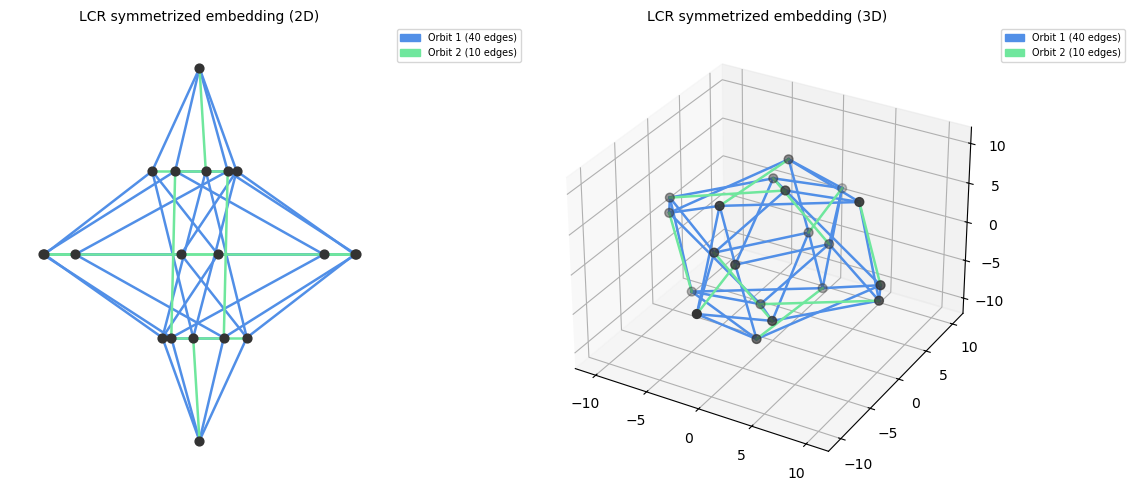

In [15]:
phi_lcr_np = np.array([float(v) for v in phi_lcr])
aut_perms = [[sigma(i) for i in range(n)] for sigma in aut_group]

from cr.viz import plot_symmetrized_embedding
fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')
plot_symmetrized_embedding(G, phi_lcr_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=2, ax=ax2d, title='LCR symmetrized embedding (2D)')
plot_symmetrized_embedding(G, phi_lcr_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=3, ax=ax3d, title='LCR symmetrized embedding (3D)')
plt.tight_layout()
plt.show()

## Part 3: Upper Conformal Rigidity ($\lambda_n$)

We repeat the same steps at the largest eigenvalue $\lambda_n$.

### Exact $\lambda_n$-eigenspace

In [16]:
lamn = sorted(L.eigenvalues())[-1]
En = (L - lamn * matrix.identity(n)).kernel()
basisn = En.basis()
dn = len(basisn)
print(f'lambda_n = {lamn.radical_expression()},  dim E_lambdan = {dn}')

lambda_n = sqrt(5) + 5,  dim E_lambdan = 7


### Orbit-isometry ideal and Gröbner basis

As with $\lambda_2$, the variety is high-dimensional and the Gröbner basis is too complex to extract a solution from directly:

In [17]:
Rn = PolynomialRing(AA, names=[f'x{i}' for i in range(dn)], order='lex')
xn = Rn.gens()

equationsn = []
for orbit in edge_orbits:
    energy = Rn(0)
    for u, v in orbit:
        phi_u = sum(xn[j] * basisn[j][u] for j in range(dn))
        phi_v = sum(xn[j] * basisn[j][v] for j in range(dn))
        energy += (phi_u - phi_v)**2
    equationsn.append(energy - len(orbit))

In = Rn.ideal(equationsn)
print(f'Ideal dimension: {In.dimension()}')

Ideal dimension: 5


In [18]:
gbn = In.groebner_basis()
print(f'Gröbner basis ({len(gbn)} elements):')
for g in gbn:
    print(g)
    print()

Gröbner basis (4 elements):
x0^2 - 53.96664627136108?*x0*x2 + 47.59674775249769?*x0*x3 + 47.59674775249769?*x0*x4 - 31.35322165454393?*x0*x5 + 87.3198679259050?*x0*x6 + 10.09016994374948?*x1^2 - 41.65993396295250?*x1*x2 + 18.94427190999916?*x1*x3 + 18.94427190999916?*x1*x4 - 7.338305413635981?*x1*x5 + 66.70644330908785?*x1*x6 - 23.26305171079445?*x2^2 + 6.204474872272383?*x2*x3 + 6.204474872272383?*x2*x4 - 20.07810245136276?*x2*x5 + 41.22684923363430?*x2*x6 + 27.41640786499874?*x3^2 + 0.8661694586364019?*x3*x4 + 11.44054284977218?*x3*x5 + 20.61342461681715?*x3*x6 + 27.41640786499874?*x4^2 + 11.44054284977218?*x4*x5 + 20.61342461681715?*x4*x6 - 7.204474872272383?*x5^2 + 20.61342461681715?*x5*x6 + 20.61342461681715?*x6^2 - 25.76678077102144?

x0*x1 + 49.89600194045229?*x0*x2 - 42.74264578624800?*x0*x3 - 42.74264578624800?*x0*x4 + 28.98332313568054?*x0*x5 - 79.11539305363262?*x0*x6 - 8.85410196624969?*x1^2 + 38.32162854931652?*x1*x2 - 16.94427190999916?*x1*x3 - 16.94427190999916?*x1*x4 + 

### Polyhedral certification ($\lambda_n$)

We can find an exact certificate using `certify_exact_ucr`, which runs the entire isotypic decomposition pipeline we did for $\lambda_2$. It returns an algebraic certificate if the graph is upper conformally rigid and only runs if $\mathcal{E}_{\lambda_n}$ decomposes into distinct irreducibles.

In [19]:
phi_ucr = certify_exact_ucr(G, aut_group, edge_orbits)
print(phi_ucr)

(0.1735387810988485?, -0.3470775621976969?, -0.3470775621976969?, 0.6278692083818614?, 0.6278692083818614?, -0.9496278036378099?, -0.1735387810988485?, -0.6278692083818614?, -0.6278692083818614?, 0.3470775621976969?, 0.3470775621976969?, 0.7351220734671776?, -0.7351220734671776?, 0.7351220734671776?, -0.7351220734671776?, -0.4543304272830130?, -0.4543304272830130?, 0.4543304272830130?, 0.4543304272830130?, 0.9496278036378099?)


We can check this is a valid 1-dimensional orbit-isometric embedding.

In [20]:
Ln_AA = G.laplacian_matrix().change_ring(AA)
print('Eigenfunction check:', all(x == 0 for x in Ln_AA * phi_ucr - lamn * phi_ucr))
for i, orbit in enumerate(edge_orbits):
    energy = sum((phi_ucr[u] - phi_ucr[v])^2 for u, v in orbit)
    print(f'Orbit {i} (size {len(orbit)}): energy = {energy.radical_expression()},  ok = {bool(energy == len(orbit))}')

Eigenfunction check: True
Orbit 0 (size 40): energy = 40,  ok = True
Orbit 1 (size 10): energy = 10,  ok = True


Finally, we plot the project symmetrized embedding

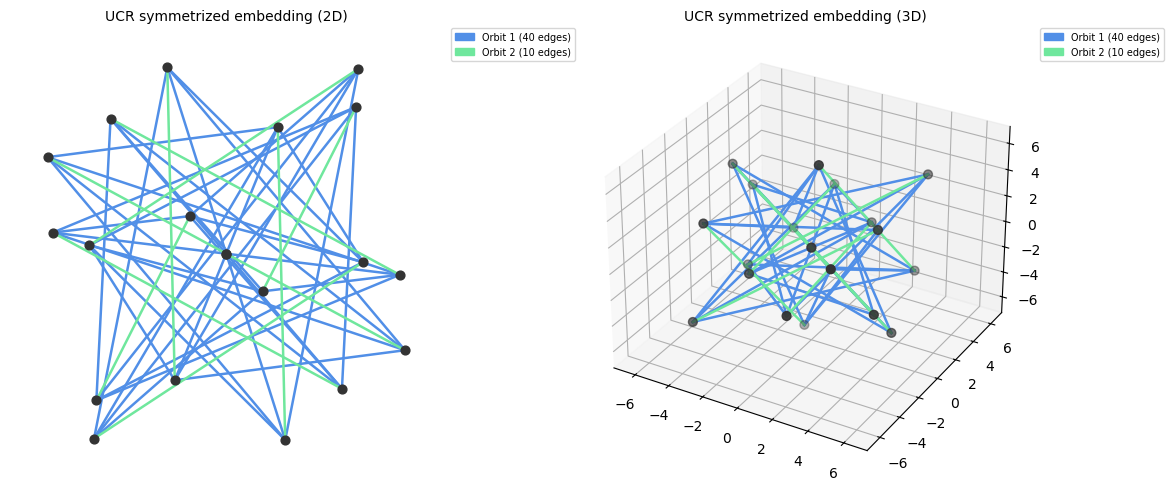

In [21]:
phi_ucr_np = np.array([float(v) for v in phi_ucr])

fig = plt.figure(figsize=(12, 5))
ax2d = fig.add_subplot(121)
ax3d = fig.add_subplot(122, projection='3d')
plot_symmetrized_embedding(G, phi_ucr_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=2, ax=ax2d, title='UCR symmetrized embedding (2D)')
plot_symmetrized_embedding(G, phi_ucr_np, aut_perms, edge_orbits=edge_orbits,
                           colors=palette, dim=3, ax=ax3d, title='UCR symmetrized embedding (3D)')
plt.tight_layout()
plt.show()